In [45]:
from openeye import oechem,oequacpac,oeomega,oeshape, oezap
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error 
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
from sys import exit
from IPython import display

In [47]:
# DATASET LOADING AND CLEANING
# ====================================
print("Dataset Loading")
print("________________")
dataset = pd.read_csv("antiviral_potency_2025_unblinded.csv")
dataset.shape
print(dataset)

print("NaNs in dataset")
print("________________")
none = dataset.isna().sum()
print(none)

print("Data without NaN values")
print("____________________________________")
clean = dataset.dropna()
clean

Dataset Loading
________________
                                               CXSMILES Molecule Name    Set  \
0     COC[C@]1(C)C(=O)N(C2=CN=CC3=CC=CC=C23)C(=O)N1C...  ASAP-0000141  Train   
1     C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC...  ASAP-0000142  Train   
2     CNC(=O)CN1C[C@]2(C[C@H](C)N(C3=CN=CC=C3C3CC3)C...  ASAP-0000143  Train   
3     C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC...  ASAP-0000144  Train   
4     C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC...  ASAP-0000145  Train   
...                                                 ...           ...    ...   
1323  O=C(CC1=CN=CC2=CC=CC=C12)N1CCCC[C@H]1[C@H]1CCC...  ASAP-0032561   Test   
1324  O=C(CC1=CN=CC2=CC=CC=C12)N1CCCC[C@H]1[C@H]1CCC...  ASAP-0032562   Test   
1325  O=C(CC1=CN=CC2=CC=CC=C12)N1CCC[C@H]2CCCC[C@@H]...  ASAP-0032572   Test   
1326  COC1=CC=CC=C1[C@H]1C[C@H](C)CCN1C(=O)CC1=CN=CC...  ASAP-0032604   Test   
1327  COC1=CC=CC=C1[C@H]1C[C@H](C)CCN1C(=O)CC1=CN=CC...  ASAP-0032605   Test   

      

,CXSMILES,Molecule Name,Set,pIC50 (MERS-CoV Mpro),pIC50 (SARS-CoV-2 Mpro)
1,C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC...,ASAP-0000142,Train,4.92,5.29
3,C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC...,ASAP-0000144,Train,4.90,6.11
4,C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC...,ASAP-0000145,Train,4.81,5.62
5,C=C(CN(C(=O)C1CCOC2=C1C=C(Cl)C=C2)C1=CN=CC2=CC...,ASAP-0000146,Train,4.88,6.45
6,C=C(CN(C(=O)C1CCOC2=C1C=C(Cl)C=C2)C1=CN=CC2=CC...,ASAP-0000147,Train,4.81,5.56
...,...,...,...,...,...
1322,O=C(CC1=CN=CC2=CC=CC=C12)N1CCCC[C@H]1[C@H]1CCC...,ASAP-0032560,Test,4.33,4.02
1323,O=C(CC1=CN=CC2=CC=CC=C12)N1CCCC[C@H]1[C@H]1CCC...,ASAP-0032561,Test,4.54,4.20
1325,O=C(CC1=CN=CC2=CC=CC=C12)N1CCC[C@H]2CCCC[C@@H]...,ASAP-0032572,Test,4.84,5.18
1326,COC1=CC=CC=C1[C@H]1C[C@H](C)CCN1C(=O)CC1=CN=CC...,ASAP-0032604,Test,5.53,5.59


In [49]:
# ATOMIC DATA COLLECTION
#=============================
smiles_col = "CXSMILES"   # change if your column is named differently
df = clean

def smiles_to_oemol(smiles: str):
    if not isinstance(smiles, str) or not smiles.strip():
        return None
    mol = oechem.OEMol()
    if not oechem.OESmilesToMol(mol, smiles):
        return None
    oechem.OEAssignAromaticFlags(mol)
    oechem.OEAddExplicitHydrogens(mol)
    return mol

mols = []
parse_ok = 0
for s in df[smiles_col].astype(str):
    m = smiles_to_oemol(s)
    mols.append(m)
    parse_ok += int(m is not None)

print("Parsed molecules:", parse_ok, "/", len(mols))

# Display information about the first few molecules
for i, m in enumerate(mols[:5]):
    print("Index:", i)
    print("Original SMILES:", df[smiles_col].iloc[i])
    
    if m is not None:
        print("Status: Success")
        print("NumAtoms:", m.NumAtoms())
        print("NumBonds:", m.NumBonds())
    else:
        print("Status: Failed")
    
    print("-" * 40)

Parsed molecules: 975 / 975
Index: 0
Original SMILES: C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC=CC=C12)C(N)=O
Status: Success
NumAtoms: 51
NumBonds: 54
----------------------------------------
Index: 1
Original SMILES: C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC=CC=C12)C(=O)OC
Status: Success
NumAtoms: 53
NumBonds: 56
----------------------------------------
Index: 2
Original SMILES: C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC=CC=C12)C(=O)O
Status: Success
NumAtoms: 50
NumBonds: 53
----------------------------------------
Index: 3
Original SMILES: C=C(CN(C(=O)C1CCOC2=C1C=C(Cl)C=C2)C1=CN=CC2=CC=CC=C12)C(=O)NC1=CC=CC=C1
Status: Success
NumAtoms: 60
NumBonds: 64
----------------------------------------
Index: 4
Original SMILES: C=C(CN(C(=O)C1CCOC2=C1C=C(Cl)C=C2)C1=CN=CC2=CC=CC=C12)C(N)=O
Status: Success
NumAtoms: 50
NumBonds: 53
----------------------------------------


In [ ]:
# 2D TO 3D CONVERSION
# ====================

# FOR MATRIX
# ============

print(f"Molecules with valid SARS-CoV-2 pIC50: {len(clean)}")

omega_opts = oeomega.OEOmegaOptions(oeomega.OEOmegaSampling_ROCS)
omega = oeomega.OEOmega(omega_opts)

mols_3d = []
skipped = 0

for smiles, name, pic50 in zip(clean["CXSMILES"],
                                clean["Molecule Name"],
                                clean["pIC50 (SARS-CoV-2 Mpro)"]):
    mol = oechem.OEMol()
    oechem.OESmilesToMol(mol, smiles)
    ret_code = omega.Build(mol)
    if ret_code == oeomega.OEOmegaReturnCode_Success:
        mol.SetTitle(name)
        oechem.OESetSDData(mol, "pIC50", str(pic50))
        mols_3d.append(oechem.OEMol(mol))
    else:
        skipped += 1

print(f"3D conformers generated: {len(mols_3d)}")
print(f"Skipped (failed): {skipped}")

# Part 2: ROCS all-vs-all comparison (demo with 50 molecules)
demo_mols = mols_3d[:50]
n = len(demo_mols)
print(f"Computing {n} x {n} ROCS similarity matrix...")

output_matrix = np.zeros((n, n))
prep = oeshape.OEOverlapPrep()

for q_idx in range(n):
    query = oechem.OEMol(demo_mols[q_idx])
    prep.Prep(query)
    overlay = oeshape.OEOverlay()
    overlay.SetupRef(query)

    for f_idx in range(n):
        fitmol = oechem.OEMol(demo_mols[f_idx])
        prep.Prep(fitmol)
        score = oeshape.OEBestOverlayScore()
        overlay.BestOverlay(score, fitmol)
        output_matrix[q_idx][f_idx] = score.GetTanimotoCombo()

    if (q_idx + 1) % 10 == 0:
        print(f"  Processed {q_idx + 1}/{n} molecules...")

print(f"\nDone! Matrix shape: {output_matrix.shape}")
print(f"Score range: {output_matrix.min():.3f} to {output_matrix.max():.3f}")


# FOR MACHINE LEARNING
# =========================
omega_opts = oeomega.OEOmegaOptions()
omega_opts.SetMaxConfs(1)
omega_opts.SetEnergyWindow(5.0)
omega_opts.SetStrictStereo(True)             
omega_opts.SetSampleHydrogens(False)
omega_opts.SetCanonOrder(True)
omega_opts.SetRMSThreshold(0.5)
omega = oeomega.OEOmega(omega_opts)

print("Processing 2d to 3d molecules for Machine Learning")
print("______________________________")
results = []

for idx, row in clean.iterrows():
    try:
        cxsmiles = row["CXSMILES"]
        mol = oechem.OEMol()
        if not oechem.OESmilesToMol(mol, cxsmiles):
            continue
            
        if mol.NumAtoms() > 80:
            print("Skipping large molecule:", row["Molecule Name"])
            continue

        oechem.OEAddExplicitHydrogens(mol)

        ret = omega.Build(mol)
        if ret != oeomega.OEOmegaReturnCode_Success:
            continue

        volume = oeshape.OECalcVolume(mol)
        pmi = oechem.OEDoubleArray(3)
        oechem.OECalcPMI(pmi, mol)

        results.append({
            "Molecule Name": row["Molecule Name"],
            "Volume": volume,
            "PMI_X": pmi[0],
            "PMI_Y": pmi[1],
            "PMI_Z": pmi[2],
            "pIC50_MERS": row["pIC50 (MERS-CoV Mpro)"],
            "pIC50_SARS2": row["pIC50 (SARS-CoV-2 Mpro)"]
        })

        del mol

        if idx % 60 == 0:
            print("Processed:", idx)
    except Exception as e:
        print("Failed index:", idx)
        continue

features_3D = pd.DataFrame(results)
features_3D.to_csv("antiviral_3D_features.csv", index=False)

Molecules with valid SARS-CoV-2 pIC50: 975
3D conformers generated: 963
Skipped (failed): 12
Computing 50 x 50 ROCS similarity matrix...
  Processed 10/50 molecules...
  Processed 20/50 molecules...
  Processed 30/50 molecules...
  Processed 40/50 molecules...
  Processed 50/50 molecules...

Done! Matrix shape: (50, 50)
Score range: 0.510 to 2.000
Processing 2d to 3d molecules
______________________________
Processed: 60
Processed: 120
Processed: 180
Processed: 300
Processed: 360
Processed: 420
Processed: 480
Processed: 540
Processed: 600
Processed: 720
Processed: 960
Processed: 1020
Processed: 1080
Processed: 1140
Processed: 1260
Processed: 1320


In [63]:
# BUILDING MACHINE LEARNING MODEL
# =====================================

print("Random Forest Model Building")
print("_____________________________")
model_df = features_3D.drop(columns=["Molecule Name"])

X = model_df.drop(columns=["pIC50_SARS2"])
y = model_df["pIC50_SARS2"]

from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(train_X, train_y)

pred = model.predict(test_X)

print(pred)

print("Error Metrics")
print("______________")
print("R2:", r2_score(test_y, pred))
print("RMSE:", np.sqrt(mean_squared_error(test_y, pred)))

Random Forest Model Building
_____________________________
[7.5719     4.16003333 4.79343333 8.43503333 5.76406667 5.20556667
 5.16933333 6.67485333 5.10176667 6.4643     5.86353333 5.25516667
 4.8249     4.4237     5.19086667 5.57176667 7.2419     5.4407
 8.06666667 5.63066667 4.1761     5.09663333 5.03503333 5.4775
 5.4841     5.13523333 4.71486667 5.3255     5.1121     6.5845
 4.97153333 6.18043333 5.1603     4.66313333 6.39146667 6.86096667
 8.4127     4.92563333 4.79766667 4.74443333 7.4928     6.1068
 4.61366667 4.5448     4.90136667 6.45776667 5.2038     5.24806667
 5.4579     4.64883333 4.60286667 6.22103333 5.03793333 6.23563333
 4.7534     4.58183333 4.5062     6.04243333 6.6603     4.44766667
 5.2898     7.2575     5.3823     5.1709     5.1171     6.94806667
 6.08663333 7.43533333 4.48923333 5.1882     7.72516667 6.32663333
 5.01426667 4.68963333 4.61746667 5.3243     5.1777     7.70673333
 5.20483333 5.32726667 5.20483333 7.71643333 6.0012     5.18986667
 5.70383333 7.37546

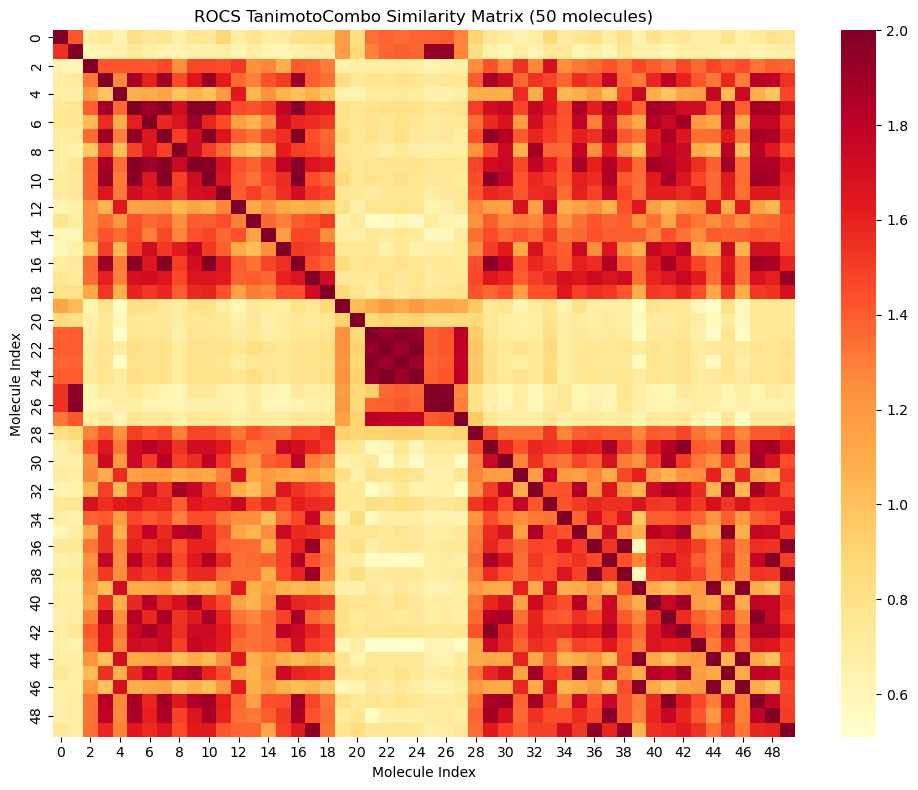

In [69]:
# SIMILARITY HEATMAP
# ===============================

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(output_matrix, cmap="YlOrRd", ax=ax)
ax.set_title("ROCS TanimotoCombo Similarity Matrix (50 molecules)")
ax.set_xlabel("Molecule Index")
ax.set_ylabel("Molecule Index")
plt.tight_layout()
plt.show()